# Permutation SHAP for Next-Token Prediction

This notebook implements permutation SHAP for token-level attribution in an
autoregressive language model. Prompt tokens are treated as features, coalitions
are evaluated as order-preserving subsequences of the original prompt, and the
value function is defined as the log-probability assigned by the model to a fixed
target token.

The goal of this notebook is to provide the direct, non-optimized SHAP
implementation. More efficient versions based on caching, batching, and prefix
reuse are studied separately in the next notebook.

Let the tokenized prompt be

$$
x_{1:T} = (x_1, \dots, x_T),
$$

and let $y$ be a fixed target token, here `" Paris"`.

For any coalition $S \subseteq \{1, \dots, T\}$, we define the value function as

$$
v(S) = \log p_\theta(y \mid x_S),
$$

where $x_S$ contains only the prompt tokens whose indices belong to $S$, while preserving their original left-to-right order.

Given a permutation $\sigma$ of the feature indices, the marginal contribution of feature $j$ is

$$
\Delta_{\sigma,j} = v(S_j^\sigma \cup \{j\}) - v(S_j^\sigma),
$$

where $S_j^\sigma$ is the set of features that appear before $j$ in permutation $\sigma$.

The basic permutation SHAP estimator is

$$
\hat{\phi}_j = \frac{1}{m} \sum_{k=1}^m \Delta_{\sigma^{(k)},j},
$$

where $m$ is the number of sampled permutations.

## Imports

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import itertools

## Load model and tokenizer

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Device:", device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Device: cpu


## Prompt and target

In [4]:
prompt = "The capital of France is"
target = " Paris"

target_display = target.strip()

## Inspect *tokenization*

Before computing target probabilities, it is important to inspect how both the prompt and the target are tokenized. In this example, the target `" Paris"` is a single token, which allows us to track its probability directly. In general, this step matters because multi-token targets would require a different treatment.

In [5]:
prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
target_ids = tokenizer(target, add_special_tokens=False)["input_ids"]

prompt_tokens = tokenizer.convert_ids_to_tokens(prompt_ids)
target_tokens = tokenizer.convert_ids_to_tokens(target_ids)

decoded_prompt_tokens = [tokenizer.decode([tid]).strip() for tid in prompt_ids]
decoded_target_tokens = [tokenizer.decode([tid]).strip() for tid in target_ids]

print("Prompt ids:", prompt_ids)
print("Prompt tokens:", prompt_tokens)
print("Target ids:", target_ids)
print("Target tokens:", target_tokens)
print("Decoded prompt tokens:", decoded_prompt_tokens)
print("Decoded target tokens:", decoded_target_tokens)

Prompt ids: [785, 6722, 315, 9625, 374]
Prompt tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']
Target ids: [12095]
Target tokens: ['ĠParis']
Decoded prompt tokens: ['The', 'capital', 'of', 'France', 'is']
Decoded target tokens: ['Paris']


In [6]:
assert len(target_ids) == 1, "This notebook assumes that the target is a single token."

target_id = target_ids[0]

## Building coalitions from token indices

Given a subset of indices $S$, we construct the corresponding input $x_S$ by selecting the tokens of the prompt indexed by $S$.

This step provides the input needed to evaluate $v(S)$ for different coalitions.

In [7]:
def build_coalition_ids(prompt_ids, selected_indices):

  ordered_indices=sorted(selected_indices)
  coalition_ids = []

  for i in ordered_indices:
    coalition_ids.append(prompt_ids[i])

  return coalition_ids

## Value function

We define a function that evaluates $v(S)$ for any coalition $S$.

Given a subset of token indices, it constructs the corresponding input and returns the log-probability of the target token as the next-token prediction.

In [8]:
def value_function(prompt_ids, selected_indices, target_id, model, device, tokenizer):

  coalition_ids=build_coalition_ids(prompt_ids, selected_indices)
  if len(coalition_ids) == 0:
    # The model requires at least one input token. We use the EOS token as a
    # simple proxy for the empty coalition.
    coalition_ids = [tokenizer.eos_token_id]

  input_tensor = torch.tensor([coalition_ids], device=device)

  model_inputs = {
      "input_ids": input_tensor,
      "attention_mask": torch.ones_like(input_tensor)
  }

  with torch.no_grad():
      outputs = model(**model_inputs)

  next_token_logits = outputs.logits[0, -1, :]
  next_token_logprobs = F.log_softmax(next_token_logits.float(), dim=-1)

  return next_token_logprobs[target_id].item()


## Marginal contributions for a single permutation

For a given permutation of token indices, we add tokens one at a time and compute the marginal contribution of each newly added token.

The resulting contributions are stored in the original token order of the prompt.

In [9]:
def get_permutation_contributions(prompt_ids, permutation, target_id, model, device, tokenizer):

    T = len(prompt_ids)
    indices_coalition = []
    contributions = [0.0] * T

    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in permutation:

        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after

    return contributions

## Permutation SHAP estimation

To estimate the contribution of each token, we first construct the full set of token-index permutations and shuffle it once.

For any given value of m, we then use the first m permutations from this shuffled list. For each of these permutations, we compute the marginal contributions and accumulate them across iterations. The final attribution for each token is obtained by averaging these contributions over the selected subset of permutations.

In [10]:
T = len(prompt_ids)
M_max = math.factorial(T)

fixed_permutations = [np.array(p) for p in itertools.permutations(range(T))]

rng = np.random.default_rng(42)
rng.shuffle(fixed_permutations)

In [11]:
def permutation_shap(prompt_ids, target_id, m, model, device, tokenizer, permutations=None):
  T=len(prompt_ids)
  shap_values=np.zeros(T)

  if permutations is None:
    permutations = [np.random.permutation(T) for _ in range(m)]
  else:
    m=len(permutations)

  for permutation in permutations:
    contributions=get_permutation_contributions(prompt_ids, permutation, target_id, model, device, tokenizer)

    shap_values+=contributions

  shap_values/=m

  return shap_values


## Estimating and displaying SHAP values

We now run the permutation SHAP estimator and display the resulting attribution for each token in the prompt.

In [12]:
m=10
sampled_permutations=fixed_permutations[:m]
shap_values=permutation_shap(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations)

In [13]:
shap_df = pd.DataFrame({
    "token": decoded_prompt_tokens,
    "shap_value": shap_values,
    "abs_shap": np.abs(shap_values)
})

shap_df_sorted = shap_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

display(shap_df_sorted.style.hide(axis="index"))

token,shap_value,abs_shap
France,5.221480,5.221480
of,3.410616,3.410616
capital,3.290676,3.290676
The,2.886366,2.886366
is,1.080161,1.080161


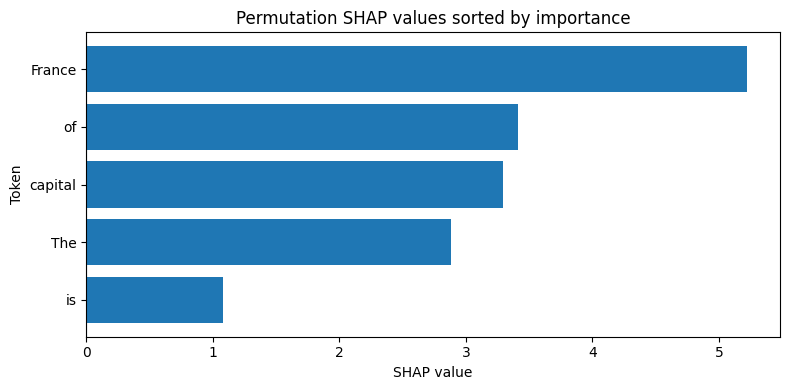

In [14]:
order = np.argsort(np.abs(shap_values))[::-1]
tokens_sorted = [decoded_prompt_tokens[i] for i in order]
values_sorted = shap_values[order]

plt.figure(figsize=(8, 4))
plt.barh(tokens_sorted, values_sorted)
plt.axvline(0)

plt.xlabel("SHAP value")
plt.ylabel("Token")
plt.title("Permutation SHAP values sorted by importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

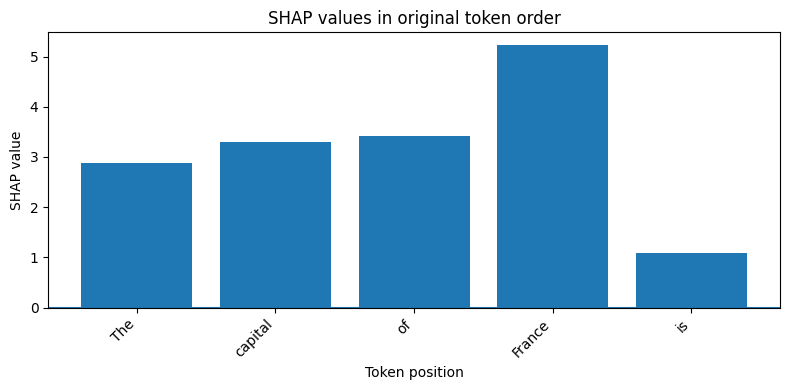

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(decoded_prompt_tokens)), shap_values)
plt.axhline(0)

plt.xticks(range(len(decoded_prompt_tokens)), decoded_prompt_tokens, rotation=45, ha="right")

plt.ylabel("SHAP value")
plt.xlabel("Token position")
plt.title("SHAP values in original token order")

plt.tight_layout()
plt.show()

## Effect of the number of permutations

We evaluate how the permutation SHAP estimates evolve as the number of sampled permutations increases.

To make the estimates directly comparable across values of m, we use the first m permutations from the same shuffled master list.

We first inspect the estimated attribution of each token as a function of m. We then compare each estimate against the exact SHAP reference computed from the full permutation set.

In [16]:
m_values = [m for m in [1, 3, 5, 10, 20, 30, 60, 120] if m <= M_max]

shap_exact = permutation_shap(prompt_ids, target_id, M_max, model, device, tokenizer, permutations=fixed_permutations)

results = {}

for m in m_values:
    sampled_permutations = fixed_permutations[:m]

    estimate = permutation_shap(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations)

    results[m] = estimate

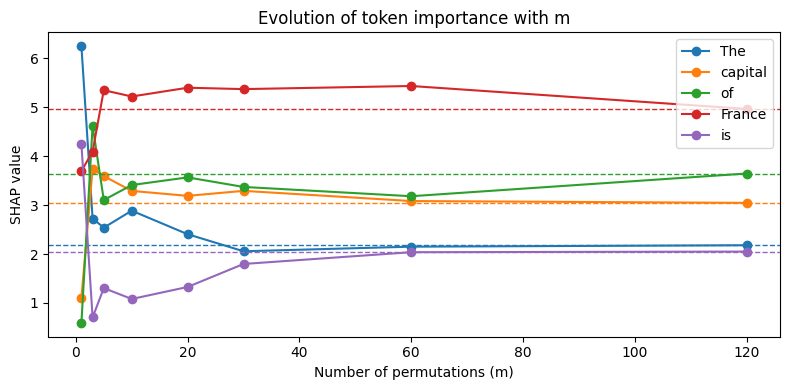

In [17]:
plt.figure(figsize=(8, 4))

for i, token in enumerate(decoded_prompt_tokens):
    y_values = [results[m][i] for m in m_values]
    line, = plt.plot(m_values, y_values, marker="o", label=token)
    plt.axhline(shap_exact[i], linestyle="--", linewidth=1, color=line.get_color())

plt.xlabel("Number of permutations (m)")
plt.ylabel("SHAP value")
plt.title("Evolution of token importance with m")
plt.legend()
plt.tight_layout()
plt.show()

## Forward/Backward Permutation SHAP

Let the tokenized prompt be

$$
x_{1:T} = (x_1, \dots, x_T),
$$

and let $y$ be a fixed target token.

For any coalition $S \subseteq \{1, \dots, T\}$, we define

$$
v(S) = \log p_\theta(y \mid x_S),
$$

where $x_S$ contains only the prompt tokens indexed by $S$, while preserving their original left-to-right order.

Let $\sigma$ be a permutation of the token indices, and let $-\sigma$ denote its reverse permutation.

For a feature $j$, its marginal contribution under permutation $\sigma$ is

$$
\Delta_{\sigma,j} = v(S_j^\sigma \cup \{j\}) - v(S_j^\sigma),
$$

where $S_j^\sigma$ is the set of features appearing before $j$ in $\sigma$.

Similarly, the marginal contribution under the reverse permutation $-\sigma$ is

$$
\Delta_{-\sigma,j} = v(S_j^{-\sigma} \cup \{j\}) - v(S_j^{-\sigma}).
$$

The forward/backward permutation SHAP estimator is then

$$
\hat{\phi}_j = \frac{1}{2m} \sum_{k=1}^m \left( \Delta_{\sigma^{(k)},j} + \Delta_{-\sigma^{(k)},j} \right),
$$

where $m$ is the number of sampled permutations.


In the implementation below, for each sampled permutation, the notebook computes
the marginal contributions in both directions and averages them to obtain the
final attribution values.

### Marginal contributions for a forward/backward permutation pair

For each sampled permutation, we compute token contributions along two trajectories: the original permutation (forward pass) and its reverse (backward pass).

By evaluating the value function along both paths, we obtain two marginal
contributions per token, which are later averaged to obtain a more symmetric and
stable estimator for the sampled permutations.

In [18]:
def get_forward_backward_contributions(prompt_ids, permutation, target_id, model, device, tokenizer):
    T=len(prompt_ids)
    forward_contributions=[0.0]*T
    backward_contributions=[0.0]*T

    reverse_permutation=permutation[::-1]

    # forward contributions
    indices_coalition=[]
    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in permutation:
        
        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        forward_contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after


    # backward contributions
    indices_coalition=[]

    v_before=value_function(prompt_ids, [], target_id, model, device, tokenizer)
    for j in reverse_permutation:
        
        v_after = value_function(prompt_ids, indices_coalition + [j], target_id, model, device, tokenizer)

        backward_contributions[j] = v_after - v_before

        indices_coalition.append(j)
        v_before = v_after

    return forward_contributions, backward_contributions

### Estimation over multiple forward/backward permutations

We now estimate the SHAP values by averaging forward and backward marginal contributions over multiple sampled permutations.

For each sampled permutation, we compute one forward pass and one backward pass, and combine both contributions in the final estimate.

Finally, we run the permutation SHAP forward-backward estimator and display the resulting attribution for each token in the prompt.

In [19]:
def permutation_shap_forward_backward(prompt_ids, target_id, m, model, device, tokenizer, permutations=None):

    T = len(prompt_ids)
    shap_values = np.zeros(T)

    if permutations is None:
        permutations = [np.random.permutation(T) for _ in range(m)]
    else:
        m = len(permutations)

    for permutation in permutations:
        forward_contributions, backward_contributions = get_forward_backward_contributions(prompt_ids, permutation, target_id, model, device, tokenizer)
        shap_values += np.array(forward_contributions) + np.array(backward_contributions)

    shap_values /= (2 * m)

    return shap_values

In [20]:
m = 10
sampled_permutations = fixed_permutations[:m]
shap_values_fb = permutation_shap_forward_backward(prompt_ids, target_id, m, model, device, tokenizer, permutations=sampled_permutations)

In [21]:
shap_fb_df = pd.DataFrame({
    "token": decoded_prompt_tokens,
    "shap_value": shap_values_fb,
    "abs_shap": np.abs(shap_values_fb)
})

shap_fb_df_sorted = shap_fb_df.sort_values("abs_shap", ascending=False)

display(shap_fb_df_sorted.style.hide(axis="index"))

token,shap_value,abs_shap
France,5.219113,5.219113
capital,3.254429,3.254429
of,3.022794,3.022794
The,2.691986,2.691986
is,1.700977,1.700977


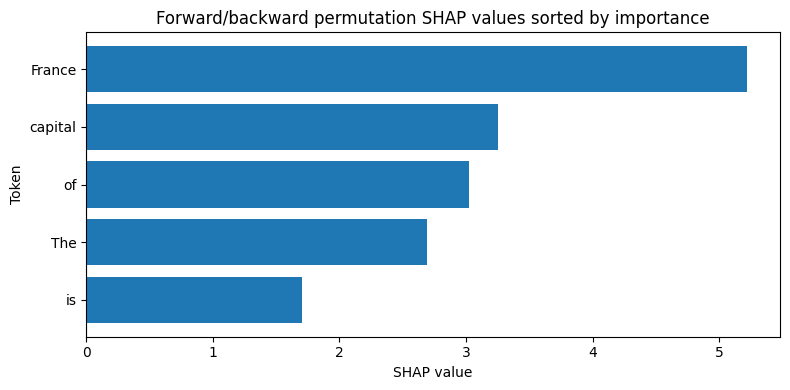

In [22]:
order = np.argsort(np.abs(shap_values_fb))[::-1]
tokens_sorted = [decoded_prompt_tokens[i] for i in order]
values_sorted = shap_values_fb[order]

plt.figure(figsize=(8, 4))
plt.barh(tokens_sorted, values_sorted)
plt.axvline(0)

plt.xlabel("SHAP value")
plt.ylabel("Token")
plt.title("Forward/backward permutation SHAP values sorted by importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Effect of the number of permutations in the forward/backward estimator

We evaluate how the forward/backward permutation SHAP estimates evolve as the number of sampled permutations increases. To make the estimates directly comparable across values of $m$, we use the first $m$ permutations from the same shuffled master list. In this experiment, we consider 
$$ 
m \in \{1,3,5,10,20,30,60,120\}.
$$
Since the prompt contains $T=5$ tokens, the full permutation space contains $5! = 120$ permutations. Therefore, the case $m=120$ corresponds to the exact forward/backward SHAP reference. We inspect the estimated attribution of each token as a function of $m$. 

In [27]:
m_values = [m for m in [1, 3, 5, 10, 20, 30, 60, 120] if m <= M_max]

results_fb = {}

for m in m_values:
    sampled_permutations = fixed_permutations[:m]

    if m == M_max:
        estimate_fb = shap_exact
    else:
        estimate_fb = permutation_shap_forward_backward(
            prompt_ids,
            target_id,
            m,
            model,
            device,
            tokenizer,
            permutations=sampled_permutations
        )

    results_fb[m] = estimate_fb

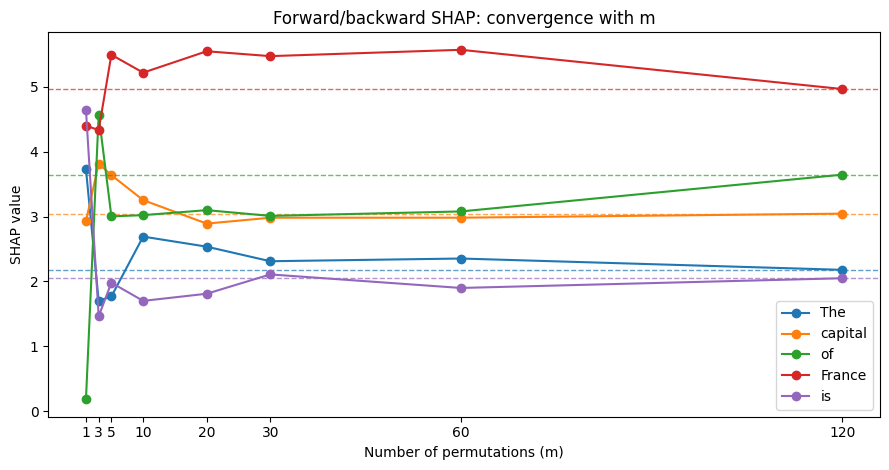

In [29]:
plt.figure(figsize=(9, 4.8))

for i, token in enumerate(decoded_prompt_tokens):
    y_values = [results_fb[m][i] for m in m_values]
    line, = plt.plot(m_values, y_values, marker="o", label=token)

    plt.axhline(
        shap_exact[i],
        linestyle="--",
        linewidth=1,
        color=line.get_color(),
        alpha=0.7
    )

plt.xlabel("Number of permutations (m)")
plt.ylabel("SHAP value")
plt.title("Forward/backward SHAP: convergence with m")
plt.xticks(m_values)
plt.legend()
plt.tight_layout()
plt.show()

## Global L2 error against the exact forward/backward SHAP reference 
The previous plot shows the convergence of each token attribution separately. To summarize this behaviour with a single metric, we compute the L2 distance between each sampled attribution vector and the exact forward/backward SHAP vector: 
$$ 
E(m)=\left\|\widehat{\boldsymbol{\phi}}^{FB,(m)}-\boldsymbol{\phi}^{FB,\mathrm{exact}}\right\|_2. 
$$
This error measures the sampling variability of the estimator with respect to the exact reference. When $m=120$, all permutations are used, so the sampled estimate coincides with the exact forward/backward SHAP value and the L2 error becomes zero.

In [32]:
l2_errors_fb = {
    m: np.linalg.norm(results_fb[m] - shap_exact)
    for m in m_values
}

l2_error_df = pd.DataFrame({
    "m": list(l2_errors_fb.keys()),
    "L2 error vs exact FB SHAP": list(l2_errors_fb.values())
})

display(l2_error_df)

,m,L2 error vs exact FB SHAP
0,1,4.631461
1,3,1.556256
2,5,1.102924
3,10,0.938395
4,20,0.919933
5,30,0.828025
6,60,0.862097
7,120,0.000000


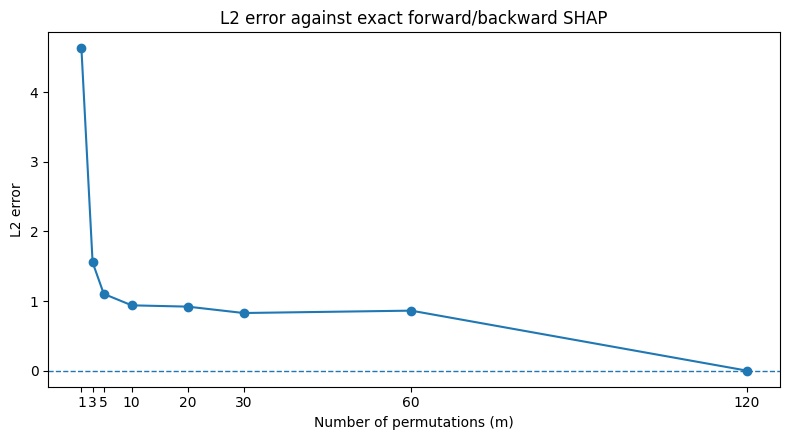

In [33]:
plt.figure(figsize=(8, 4.5))

plt.plot(
    list(l2_errors_fb.keys()),
    list(l2_errors_fb.values()),
    marker="o"
)

plt.xlabel("Number of permutations (m)")
plt.ylabel("L2 error")
plt.title("L2 error against exact forward/backward SHAP")
plt.xticks(m_values)
plt.axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## Summary

This notebook implemented direct permutation SHAP estimators for next-token
prediction. The first implementation estimates SHAP values by averaging marginal
contributions over sampled permutations. The second implementation uses both
forward and backward traversal for each sampled permutation.

These implementations provide the reference methods used in the following
notebook, where the same attribution problem is studied with more efficient
evaluation strategies such as caching, batching, and prefix reuse.